# Task 4: Forecasting Access and Usage

This notebook generates forecasts for key financial inclusion indicators in Ethiopia. Given the sparse nature of the data (e.g., Global Findex surveys every 3-4 years), we use simple linear regression to estimate trends and project values up to 2030.

## Objectives
1. **Baseline Forecast**: Project current trends into the future.
2. **Scenario Analysis**: Estimate outcomes under Optimistic (High Growth) and Pessimistic (Low Growth) scenarios.\n
3. **Uncertainty Quantification**: Provide 95% confidence intervals for the baseline forecasts.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sys
import os

# Add src to path
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), '../src')))
from utils import calculate_forecast, save_fig, save_summary, logger

## 1. Load Data

In [2]:
data_path = '../data/raw/ethiopia_fi_unified_data.csv'
df = pd.read_csv(data_path)
print(f"Loaded {len(df)} records.")

Loaded 43 records.


# 2. Generate Forecasts

We use the `calculate_forecast` utility which implements Linear Regression with Confidence Intervals.

In [3]:
indicators = [
    'ACC_OWNERSHIP',      # Account Ownership
    'ACC_MM_ACCOUNT',     # Mobile Money Account
]

all_forecasts = []

for ind in indicators:
    print(f"Forecasting {ind}...")
    forecast_df = calculate_forecast(df, ind, years_ahead=5)
    if not forecast_df.empty:
        forecast_df['indicator'] = ind
        forecast_df['scenario'] = 'Baseline'
        all_forecasts.append(forecast_df)
        
        # Display last few years
        display(forecast_df.tail())

Forecasting ACC_OWNERSHIP...


,year,value,lower_ci,upper_ci,type,value_numeric,final_value,indicator,scenario
5,2026,65.154378,36.075766,94.232990,Forecast,NaN,65.154378,ACC_OWNERSHIP,Baseline
6,2027,68.732719,38.353753,99.111685,Forecast,NaN,68.732719,ACC_OWNERSHIP,Baseline
7,2028,72.311060,40.491729,104.130390,Forecast,NaN,72.311060,ACC_OWNERSHIP,Baseline
8,2029,75.889401,42.507813,109.270989,Forecast,NaN,75.889401,ACC_OWNERSHIP,Baseline
9,2030,79.467742,44.418300,114.517183,Forecast,NaN,79.467742,ACC_OWNERSHIP,Baseline


Forecasting ACC_MM_ACCOUNT...


/home/karanos/kiam/week10/prod/src/utils.py:289: RuntimeWarning: divide by zero encountered in scalar divide
  mse = sum_squared_residuals / dof


,year,value,lower_ci,upper_ci,type,value_numeric,final_value,indicator,scenario
2,2025,11.033333,NaN,NaN,Forecast,NaN,11.033333,ACC_MM_ACCOUNT,Baseline
3,2026,12.616667,NaN,NaN,Forecast,NaN,12.616667,ACC_MM_ACCOUNT,Baseline
4,2027,14.200000,NaN,NaN,Forecast,NaN,14.200000,ACC_MM_ACCOUNT,Baseline
5,2028,15.783333,NaN,NaN,Forecast,NaN,15.783333,ACC_MM_ACCOUNT,Baseline
6,2029,17.366667,NaN,NaN,Forecast,NaN,17.366667,ACC_MM_ACCOUNT,Baseline


## 3. Scenario Analysis

We apply multipliers to the projected growth: 
- **Optimistic**: 15% faster growth
- **Pessimistic**: 15% slower growth

In [4]:
baseline_results = pd.concat(all_forecasts) if all_forecasts else pd.DataFrame()

if not baseline_results.empty:
    scenarios = [
        {'name': 'Optimistic', 'multiplier': 1.15},
        {'name': 'Pessimistic', 'multiplier': 0.85}
    ]
    
    for scenario in scenarios:
        scenario_df = baseline_results.copy()
        scenario_df['scenario'] = scenario['name']
        
    
        pass

## 4. Visualization

Plots generated by the analysis script are saved in `data/reportdata/figures`.

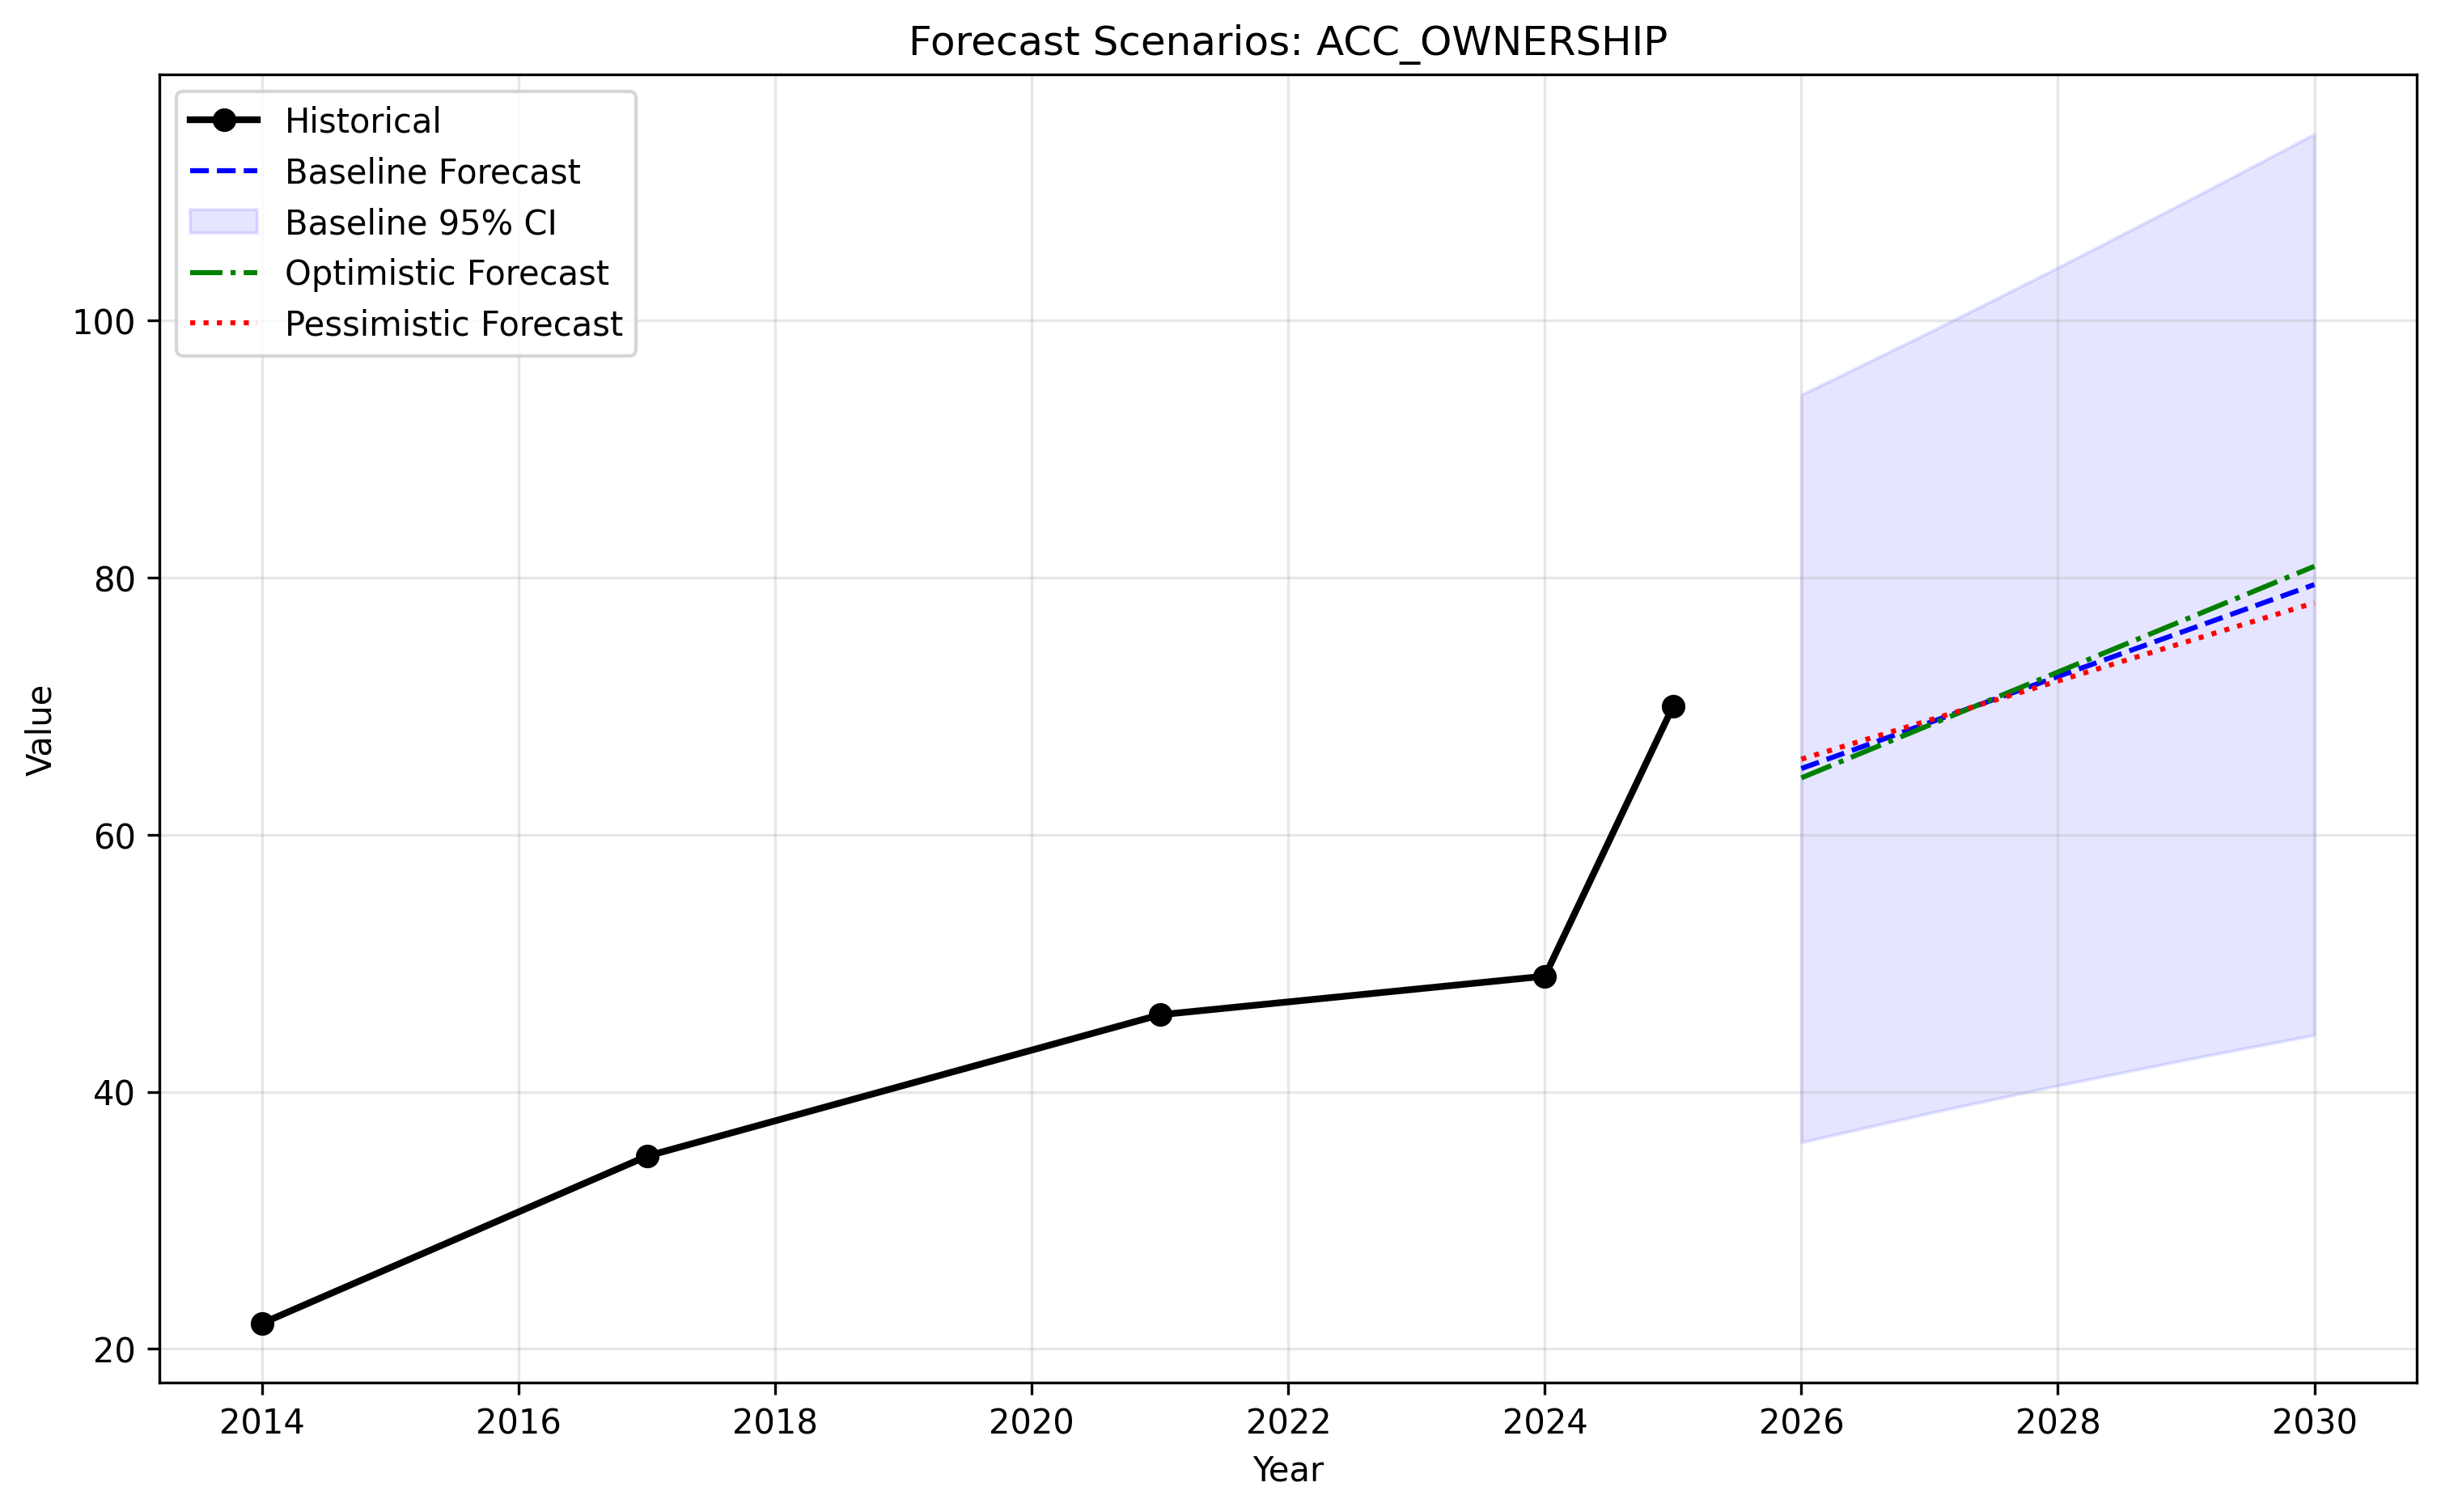

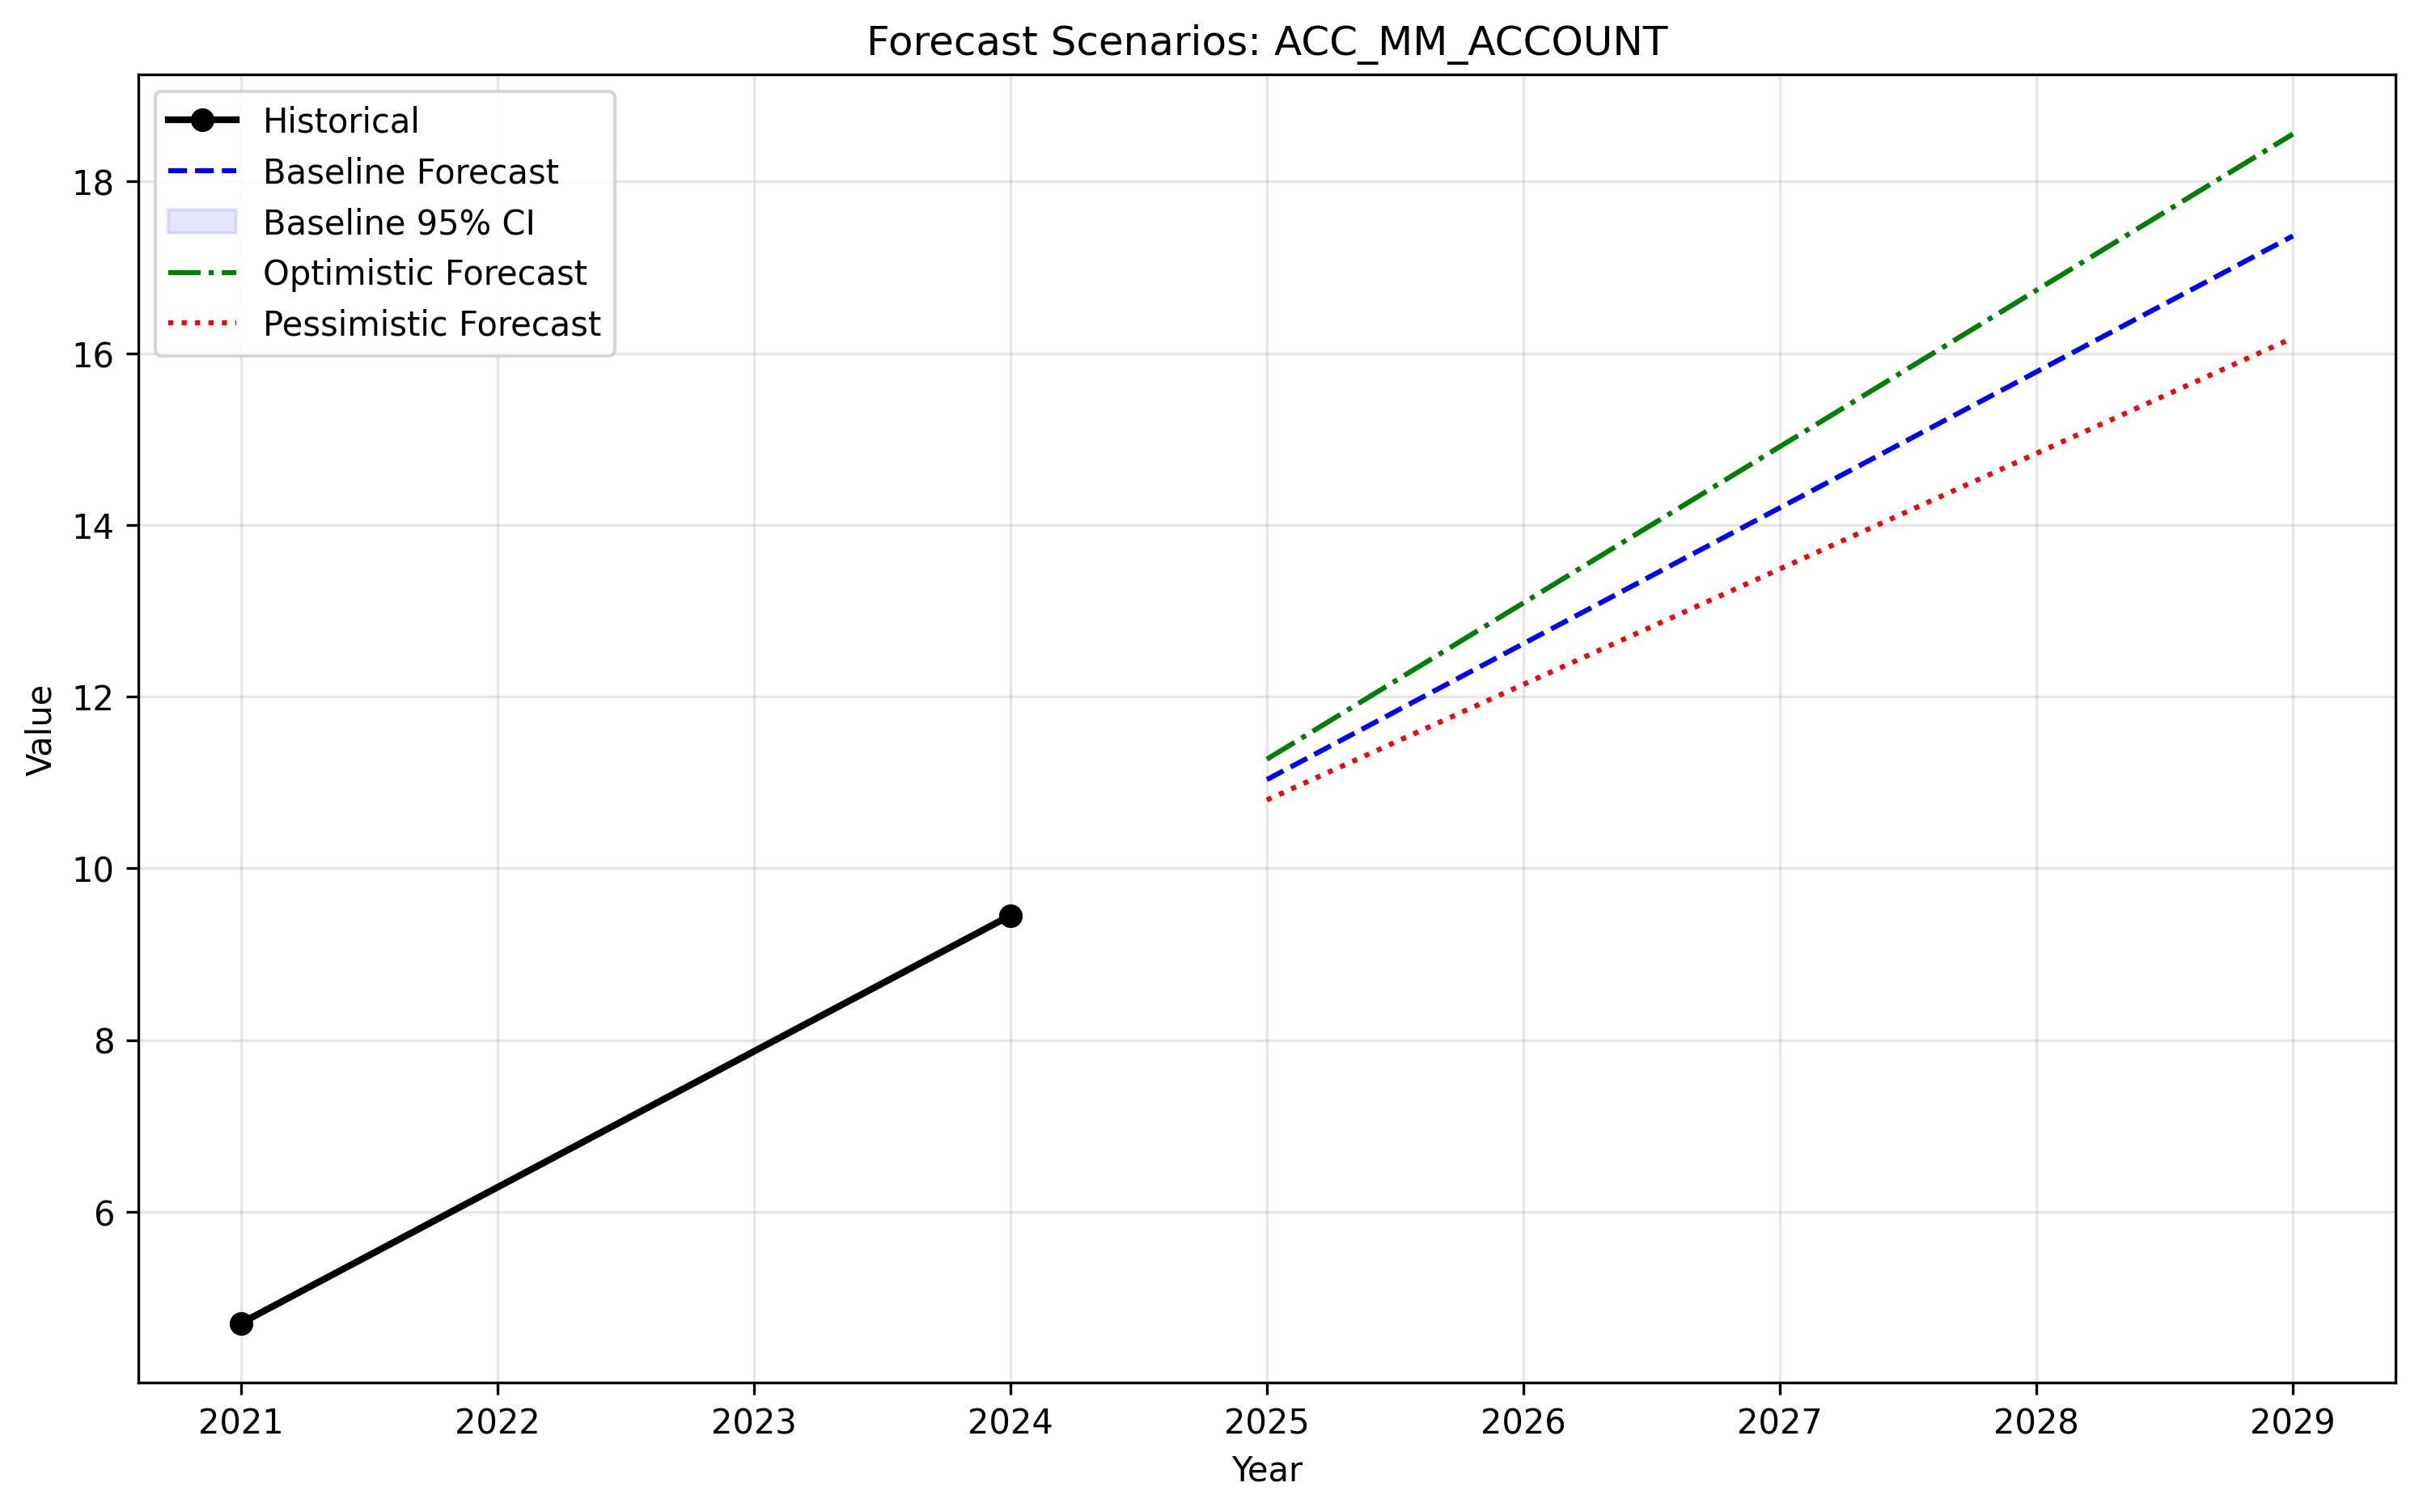

In [5]:
from IPython.display import Image, display
import glob

figures = glob.glob('../data/reportdata/figures/forecast_scenarios_*.png')
for fig in figures:
    display(Image(filename=fig))